<a href="https://colab.research.google.com/github/Salsabila-002/UAS_BIGDATA_KELOMPOK8/blob/main/Project_Bigdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##PRAKTIKUM BIG DATA
1. Salsabila Fitri Ramadhani - 2310511002
2. Najwa Khaylawati - 2310511008
3. Nurhaliza - 2310511028

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving output_retail.csv to output_retail.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('output_retail.csv', sep=';', engine='python')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01/12/2010,425,17850,United Kingdom,2550.0
1,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01/12/2010,765,17850,United Kingdom,1530.0
2,536365,71053,WHITE METAL LANTERN,6,01/12/2010,339,17850,United Kingdom,2034.0
3,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010,339,17850,United Kingdom,2034.0
4,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010,339,17850,United Kingdom,2034.0


# **Data Quality**

In [ ]:
df.shape

(392797, 9)

In [ ]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0
TotalPrice,0


# **Inforomasi Data Duplikat**

In [ ]:
df.duplicated().sum()

np.int64(105)

In [ ]:
# Menghapus data duplikat
df = df.drop_duplicates()

# Mengecek ulang jumlah data duplikat
df.duplicated().sum()

np.int64(0)

# **Informasi Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 392796
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      392692 non-null  int64  
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   Price        392692 non-null  object 
 6   Customer ID  392692 non-null  int64  
 7   Country      392692 non-null  object 
 8   TotalPrice   392692 non-null  float64
dtypes: float64(1), int64(3), object(5)
memory usage: 30.0+ MB


In [ ]:
# Convert Price ke numeric
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Membuat Total Revenue
df['TotalRevenue'] = (
    df['Quantity'] * df['Price']
)

print("\nPreprocessing Selesai")


Preprocessing Selesai


In [ ]:
X = df[
    ['Quantity', 'Price', 'TotalRevenue']
].copy()

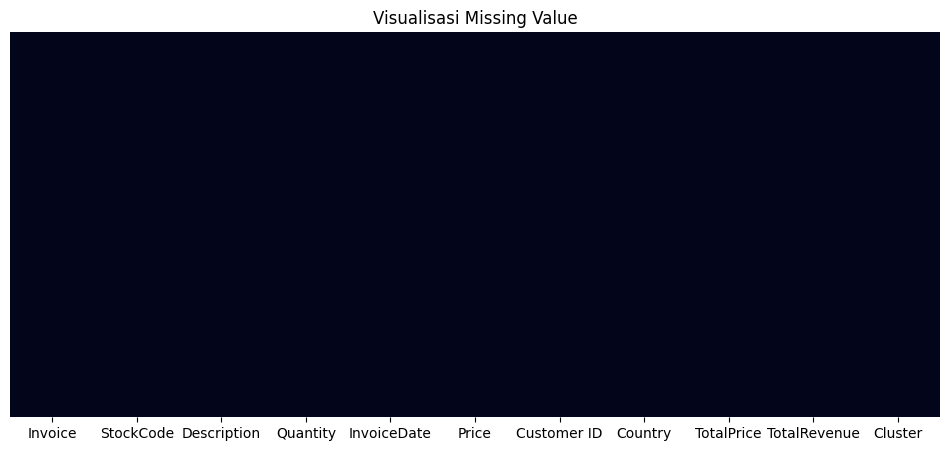

In [ ]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title('Visualisasi Missing Value')

plt.show()

# **DATA DESCRIPTIVE**

In [ ]:
print("\nStatistik Deskriptif:")
print(df[['Quantity', 'Price', 'TotalRevenue']].describe())


Statistik Deskriptif:
            Quantity          Price  TotalRevenue
count  392692.000000  392692.000000  3.926920e+05
mean       13.119699     226.571959  1.961791e+03
std       180.492832     208.584317  3.021920e+04
min         1.000000       1.000000  1.000000e+00
25%         2.000000      85.000000  3.300000e+02
50%         6.000000     165.000000  1.008000e+03
75%        12.000000     295.000000  1.770000e+03
max     80995.000000     998.000000  1.684696e+07


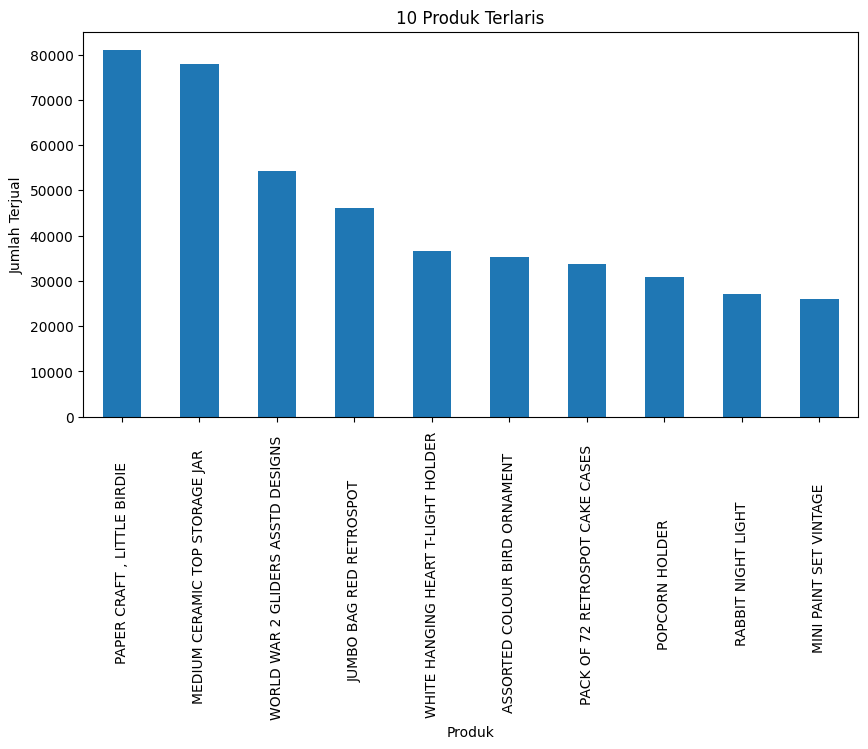

In [ ]:
top_produk = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_produk.plot(kind='bar')

plt.title('10 Produk Terlaris')

plt.xlabel('Produk')

plt.ylabel('Jumlah Terjual')

plt.show()

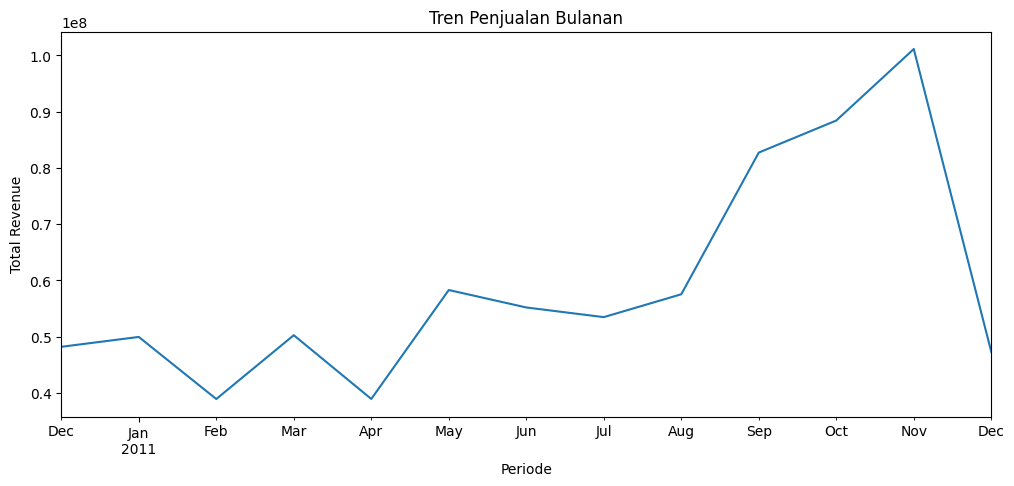

In [ ]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

# Create YearMonth for grouping
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = (
    df.groupby('YearMonth')['TotalRevenue']
    .sum()
)

plt.figure(figsize=(12,5))
monthly_sales.plot()

plt.title('Tren Penjualan Bulanan')
plt.xlabel('Periode')
plt.ylabel('Total Revenue')
plt.show()

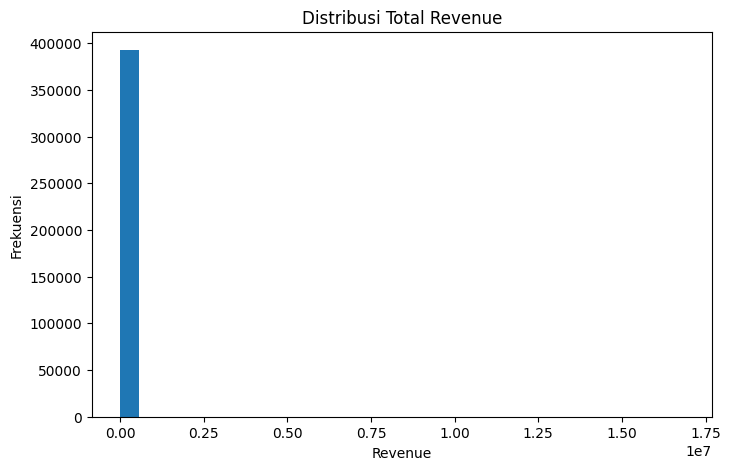

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df['TotalRevenue'],
    bins=30
)

plt.title('Distribusi Total Revenue')

plt.xlabel('Revenue')

plt.ylabel('Frekuensi')

plt.show()

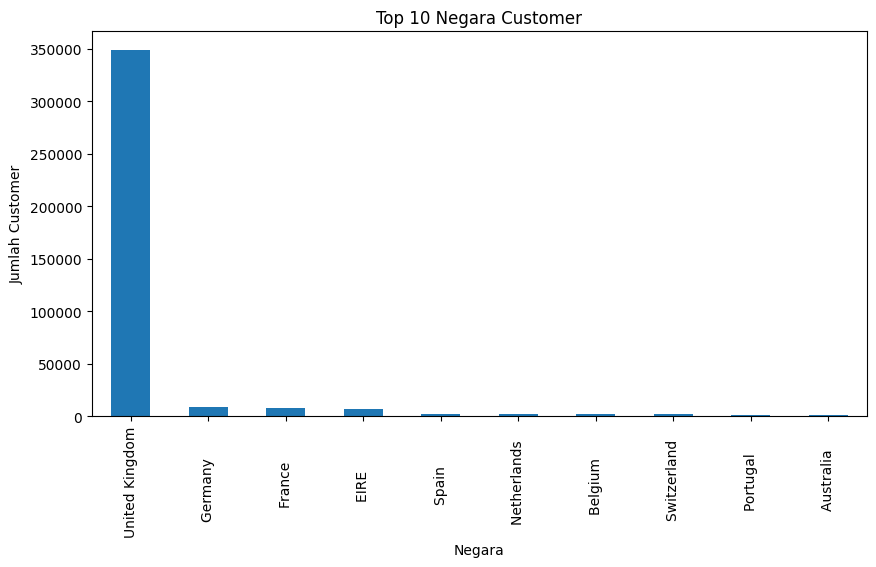

In [ ]:
# Negara customer terbanyak
top_country = (
    df['Country']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

top_country.plot(kind='bar')

plt.title('Top 10 Negara Customer')

plt.xlabel('Negara')

plt.ylabel('Jumlah Customer')

plt.show()

# **CUSTOMER SEGMENTATION (RFM)**

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalRevenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("\nRFM:")
print(rfm.head())


RFM:
             Recency  Frequency     Monetary
Customer ID                                 
12346            326          1  7718360.000
12347              3          7   406386.125
12348             76          4   144084.000
12349             19          1   124879.800
12350            311          1    20408.000


In [ ]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

# **ELBOW METHOD**

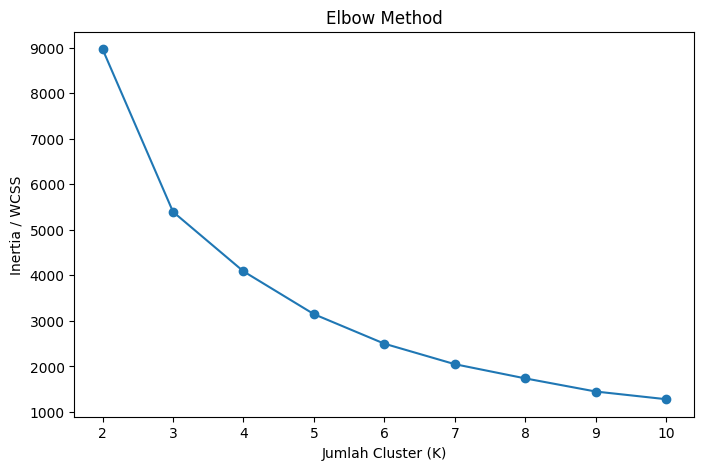

In [ ]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

# VISUALISASI ELBOW
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia / WCSS')

plt.show()

# **K-MEANS CLUSTERING**

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
print(rfm[['Recency', 'Frequency', 'Monetary', 'Cluster']].head(10))

             Recency  Frequency     Monetary  Cluster
Customer ID                                          
12346            326          1  7718360.000        2
12347              3          7   406386.125        0
12348             76          4   144084.000        0
12349             19          1   124879.800        0
12350            311          1    20408.000        1
12352             37          8   123373.520        0
12353            205          1     8900.000        1
12354            233          1    97608.675        1
12355            215          1    43392.550        1
12356             23          3   195905.215        0


# **SILHOUETTE SCORE**

In [ ]:
sil_score = silhouette_score(
    rfm_scaled,
    rfm['Cluster']
)

print("\nSilhouette Score:")
print(round(sil_score, 3))


Silhouette Score:
0.593


# **PROFIL CLUSTER**

In [ ]:
cluster_profile = rfm.groupby('Cluster').mean()

print("\nProfil Cluster:")
print(cluster_profile)


Profil Cluster:
            Recency  Frequency      Monetary
Cluster                                     
0         41.699255   4.686220  1.634017e+05
1        246.649541   1.579817  4.306150e+04
2         18.807692  65.807692  7.575482e+06


# **VISUALISASI CLUSTER**

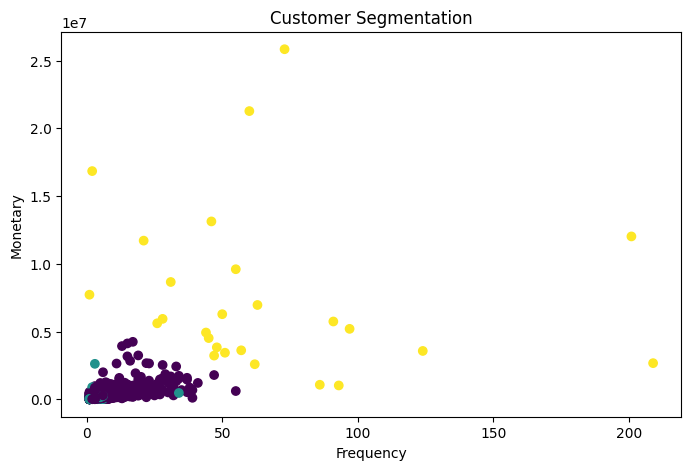

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.title('Customer Segmentation')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.show()

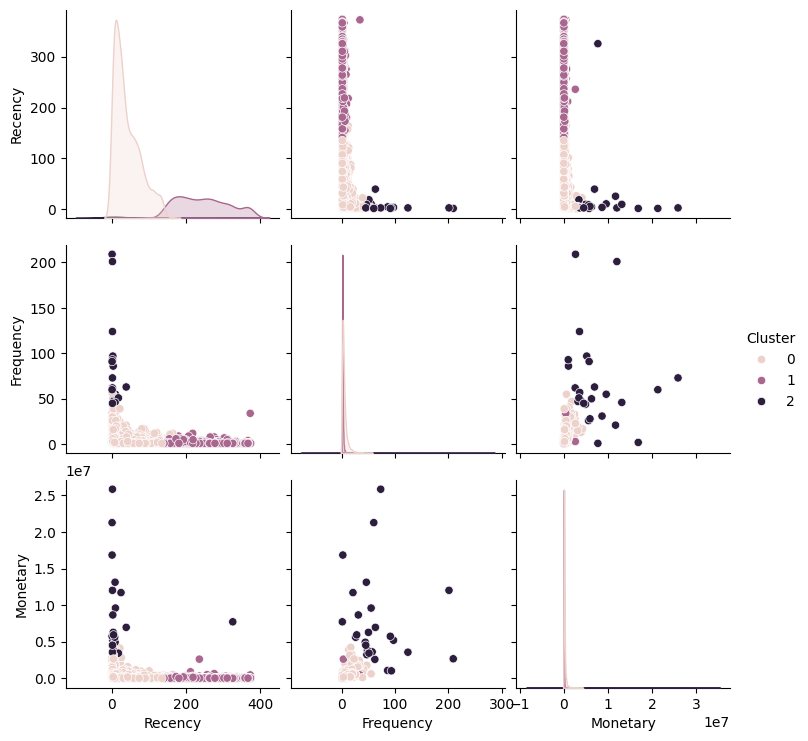

In [ ]:
import seaborn as sns

sns.pairplot(
    rfm,
    hue='Cluster'
)

plt.show()

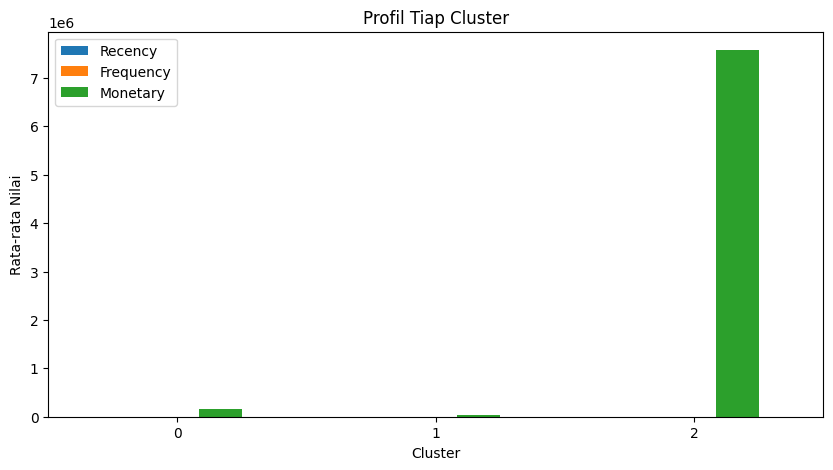

In [ ]:
cluster_profile.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Profil Tiap Cluster')

plt.ylabel('Rata-rata Nilai')

plt.xticks(rotation=0)

plt.show()

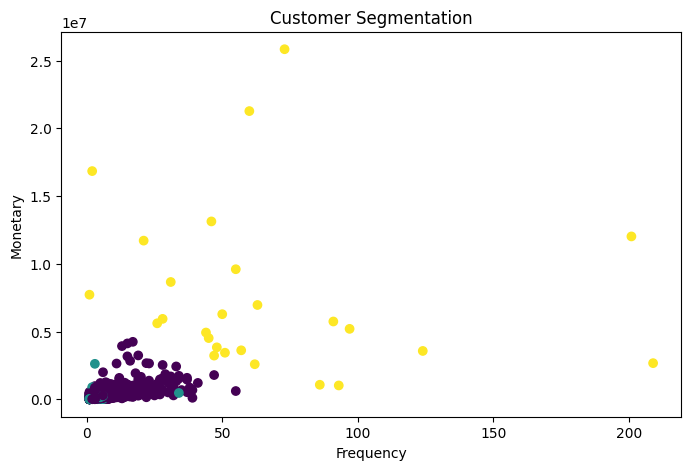

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.title('Customer Segmentation')

plt.xlabel('Frequency')

plt.ylabel('Monetary')

plt.show()